# Time Series Analysis

A TimeSeries in **Pandas** is a DataFrame with a regular interval datetime index. This notebook gives an introduction to TimeSeries in **Pandas**.

In the following notebooks, we will discuss two families of forecast model, ETS and ARIMA.

In [1]:
# Import the required packages

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the airlines_passenger data

airlines_df = pd.read_csv('airline_passengers.csv')
airlines_df.head()

,Month,Thousands of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
# Create a TimeSeries variable named airlines_series by assigning a datetime to the index

airlines_series = airlines_df['Thousands of Passengers']
airlines_series.index = pd.DatetimeIndex(airlines_df['Month'])
airlines_series

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Thousands of Passengers, Length: 144, dtype: int64

When setting the TimeSeries index, we may need to specify the frequency (though this is usually calculated by default).

The syntax for specifying the index frequency is:
> <span style="color:blue">\# *Set the index frequency to MS*</span><br>
Series.index.freq = 'MS'

In this example, *Series* is the name of the TimeSeries variable and *MS* refers to the frequency code corresponding to the start of the month (as per the data). The following table lists some of the frequency codes and descriptions of each. This may be useful for reference and is also available [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases).

| Frequency Code | Description |
| --- | --- |
| A | Year End |
| AS | Year Start |
| Q | Quarter End |
| M | Month End |
| **MS** | **Month Start** |
| BM | Business Month End |
| BMS | Business Month Start |
| W | Week |
| D | Day |
| B | Business Day |
| H | Hour |
| T | Minutes |
| S | Seconds |

In [4]:
airlines_series.index.freq = 'MS'

Pandas brings in functionality for working with TimeSeries that we can now make use of.

In [5]:
# Select the data for the year 1959

airlines_series['1959']

Month
1959-01-01    360
1959-02-01    342
1959-03-01    406
1959-04-01    396
1959-05-01    420
1959-06-01    472
1959-07-01    548
1959-08-01    559
1959-09-01    463
1959-10-01    407
1959-11-01    362
1959-12-01    405
Freq: MS, Name: Thousands of Passengers, dtype: int64

In [6]:
# Select the data for 1959 onwards

airlines_series['1959':]

Month
1959-01-01    360
1959-02-01    342
1959-03-01    406
1959-04-01    396
1959-05-01    420
1959-06-01    472
1959-07-01    548
1959-08-01    559
1959-09-01    463
1959-10-01    407
1959-11-01    362
1959-12-01    405
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: Thousands of Passengers, dtype: int64

In [7]:
# Select the data for the month July 1958

airlines_series['July 1958']

Month
1958-07-01    491
Freq: MS, Name: Thousands of Passengers, dtype: int64

<AxesSubplot:xlabel='Month'>

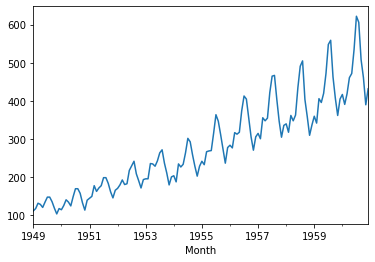

In [8]:
# Plot the TimeSeries

airlines_series.plot()

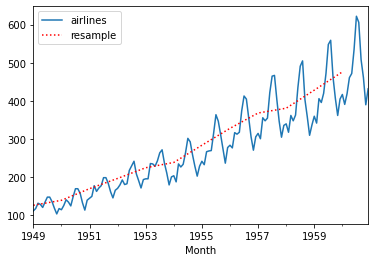

In [9]:
# Aggregate the data to a higher level of detail using the .resample() method

airlines_series.plot()
airlines_series.resample('YS').mean().plot(style=':',color='red') # resample aggregates across each time step
    # in this example, the aggregation used is mean
    
plt.legend(['airlines','resample'])

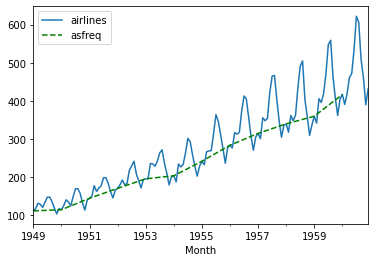

In [11]:
# Aggregate the data to a higher level of detail using the .resample() or .asfreq() methods

airlines_series.plot()
airlines_series.asfreq('YS').plot(style='--',color='green') # asfreq picks the value at each time step
plt.legend(['airlines','asfreq'])

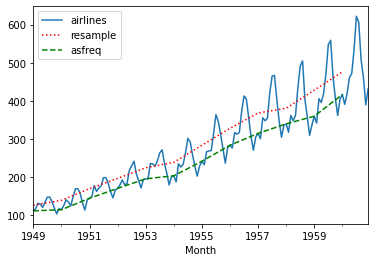

In [12]:
# Aggregate the data to a higher level of detail using the .resample() method

airlines_series.plot()
airlines_series.resample('YS').mean().plot(style=':',color='red') # resample aggregates across each time step
    # in this example, the aggregation used is mean
airlines_series.asfreq('YS').plot(style='--',color='green') # asfreq picks the value at each time step
plt.legend(['airlines','resample','asfreq'])

<AxesSubplot:xlabel='Month'>

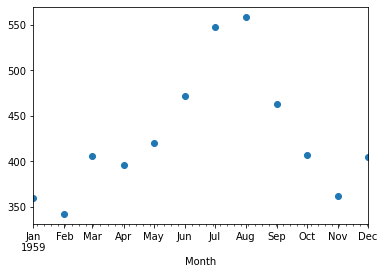

In [13]:
# Up-sample the data to a lower level of detail using the .asfreq() method
# As a default, all unspecified data is N/A

airlines_series['1959'].asfreq('D').plot(marker='o')

In [14]:
airlines_series['1959'].asfreq('D')

Month
1959-01-01    360.0
1959-01-02      NaN
1959-01-03      NaN
1959-01-04      NaN
1959-01-05      NaN
              ...  
1959-11-27      NaN
1959-11-28      NaN
1959-11-29      NaN
1959-11-30      NaN
1959-12-01    405.0
Freq: D, Name: Thousands of Passengers, Length: 335, dtype: float64

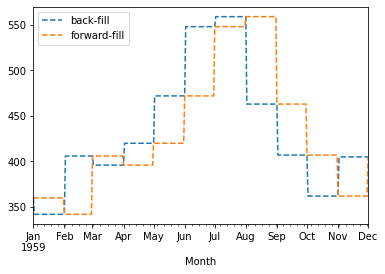

In [15]:
# Up-sample the data to a lower level of detail using the .asfreq() method
# Specify the method for imputing empty values
#     bfill - back-fill empty values using the next value
#     ffill - forward-fill empty values using the last value

airlines_series['1959'].asfreq('D',method='bfill').plot(style='--')
airlines_series['1959'].asfreq('D',method='ffill').plot(style='--')
plt.legend(['back-fill','forward-fill'])

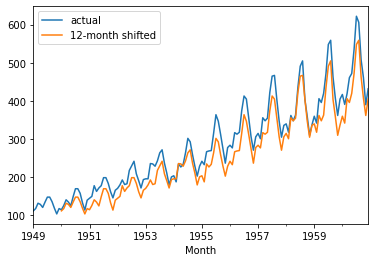

In [16]:
# Shift the data using the .shift() method

airlines_series.plot()
airlines_series.shift(12).plot()
plt.legend(['actual','12-month shifted'])

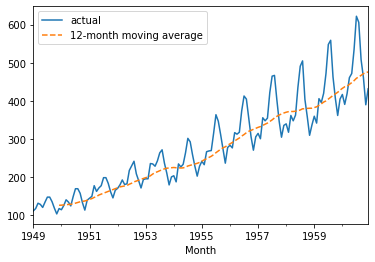

In [16]:
# Create rolling calculations (e.g. moving average) using the .rolling() method

rolling = airlines_series.rolling(12)
airlines_series.plot()
rolling.mean().plot(style='--')
plt.legend(['actual','12-month moving average'])

##### Why is the moving average important?

In statistics, it is common to take the mean of the data to be the best guess (or least-worst guess) for what will happen next. In a TimeSeries, there is an order to the data, so at **each time step** the **running average** is our best guess for what will happen next. However, to account for trends and seasonalities, a **moving average** is often used instead as it only takes into account data from the last *n* time steps.  

# Exercises

##### Guide
Attempt the questions in order. If you get stuck, ask your PDE. 

After you've finished the exercises, find some interesting open source time series data online and work your way through the exercises with your new data. (A good source of interesting data is [here](https://github.com/jbrownlee/Datasets).)

In [77]:
# Read the sunspots per month from the URL below using the pd.read_csv() function
# https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv')
</details>

In [76]:
# Convert this into a TimeSeries with the correct index frequency



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots_series = sunspots['Sunspots']<br>
sunspots_series.index = pd.DatetimeIndex(sunspots['Month'])
</details>

In [75]:
# Plot the number of sunspots over time



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots_series.plot()
</details>

In [74]:
# Find the average number of sunspots per month in 1969



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots_series['1969'].mean()
</details>

In [73]:
# Calculate the 12-month moving average number of sunspots



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots_series.rolling(72).mean()
</details>

In [72]:
# Plot the 6-year moving average number of sunspots



<details>
    <summary style="color:green;font-weight:bold">Click here for the answer</summary>
    
> sunspots_series.rolling(72).mean().plot()
</details>